In [93]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1. Download 10 Years of NIFTY50 Market Data
print("Downloading NIFTY50 historical data...")
nifty_info = yf.Ticker('^NSEI')
nifty_history = nifty_info.history(period='10y')
series = nifty_history['Close'].dropna()

# 2. Complete 80/20 Train/Test Data Partitioning
n_total = len(series)
n_train = int(n_total * 0.8)
n_test = n_total - n_train

train_series = series.iloc[:n_train]
test_series = series.iloc[n_train:]

print(f"\n--- Data Setup Complete ---")
print(f"Total Framework Records: {n_total} trading days")
print(f"Training Subset (80%):  {n_train} trading days")
print(f"Testing Subset  (20%):  {n_test} trading days")


--- Data Setup Complete ---
Total Framework Records: 2462 trading days
Training Subset (80%):  1969 trading days
Testing Subset  (20%):  493 trading days


==================== STATIONARITY ANALYSIS ====================
Raw Series (d=0) ADF p-value: 0.9849
First-Differenced Series (d=1) ADF p-value: 2.5216e-30
Conclusion: First-difference is stationary. Using d = 1 baseline.



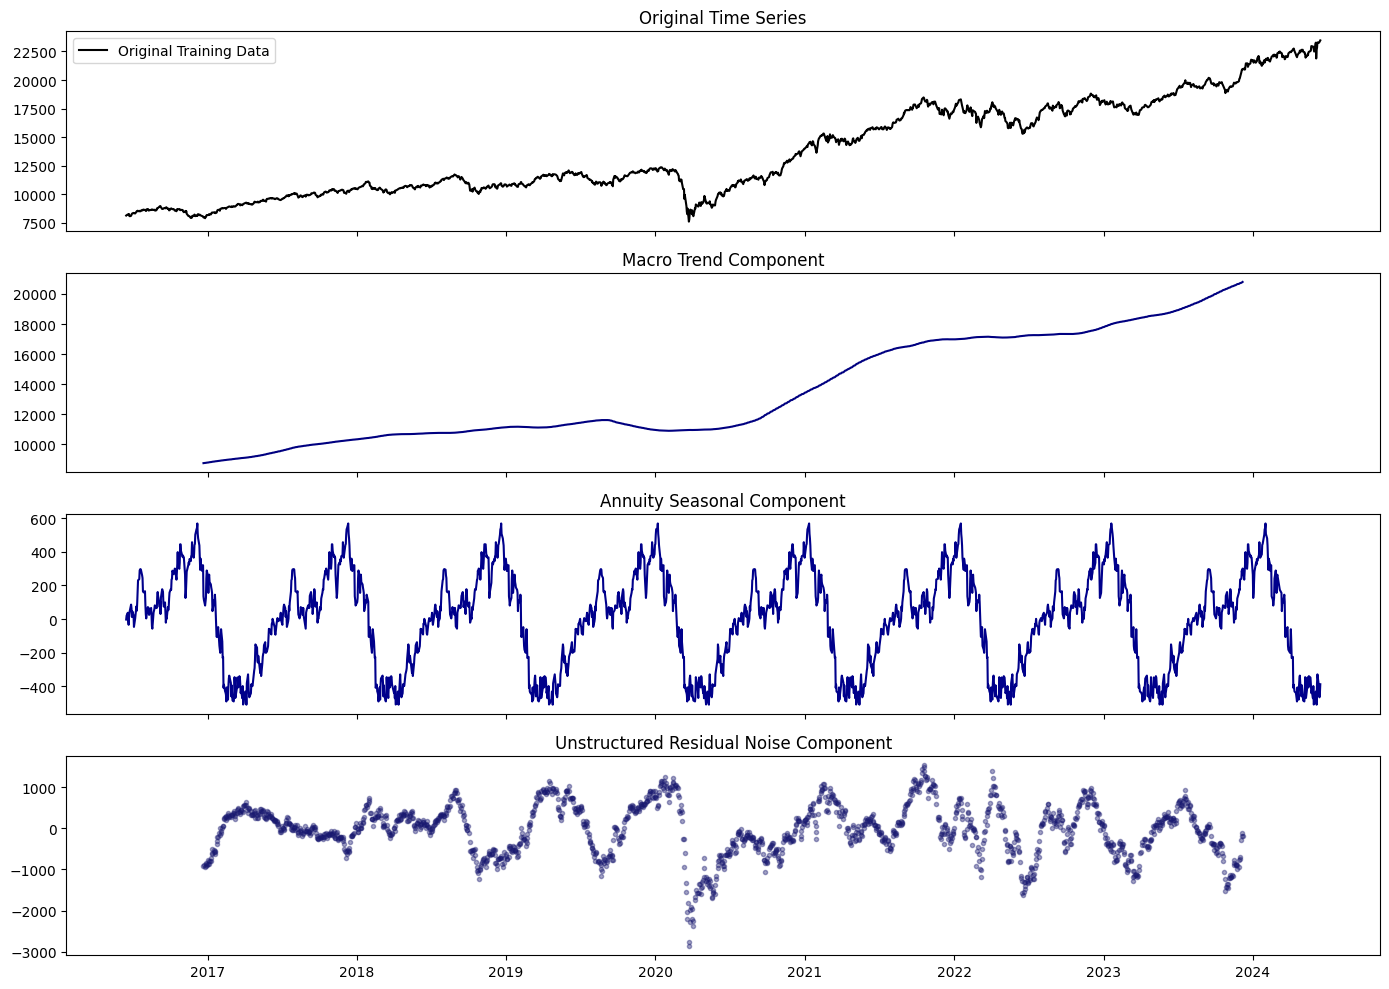

In [94]:
# 1. Integrated Stationarity (d-value) Diagnostics
print("==================== STATIONARITY ANALYSIS ====================")
p_val_raw = adfuller(train_series)[1]
print(f"Raw Series (d=0) ADF p-value: {p_val_raw:.4f}")

stationary_train = train_series.diff(1).dropna()
p_val_diff = adfuller(stationary_train)[1]
print(f"First-Differenced Series (d=1) ADF p-value: {p_val_diff:.4e}")
print("Conclusion: First-difference is stationary. Using d = 1 baseline.\n")

# 2. Additive Macro Seasonal Decomposition (Calculated strictly on historical train set)
decomposition = seasonal_decompose(train_series, period=252, model="additive")

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
ax1.plot(train_series, label="Original Training Data", color='black')
ax1.set_title("Original Time Series")
ax1.legend(loc='upper left')

ax2.plot(decomposition.trend, color='navy')
ax2.set_title("Macro Trend Component")

ax3.plot(decomposition.seasonal, color='darkblue')
ax3.set_title("Annuity Seasonal Component")

ax4.plot(decomposition.resid, '.', color='midnightblue', alpha=0.4)
ax4.set_title("Unstructured Residual Noise Component")

plt.tight_layout()
plt.show()

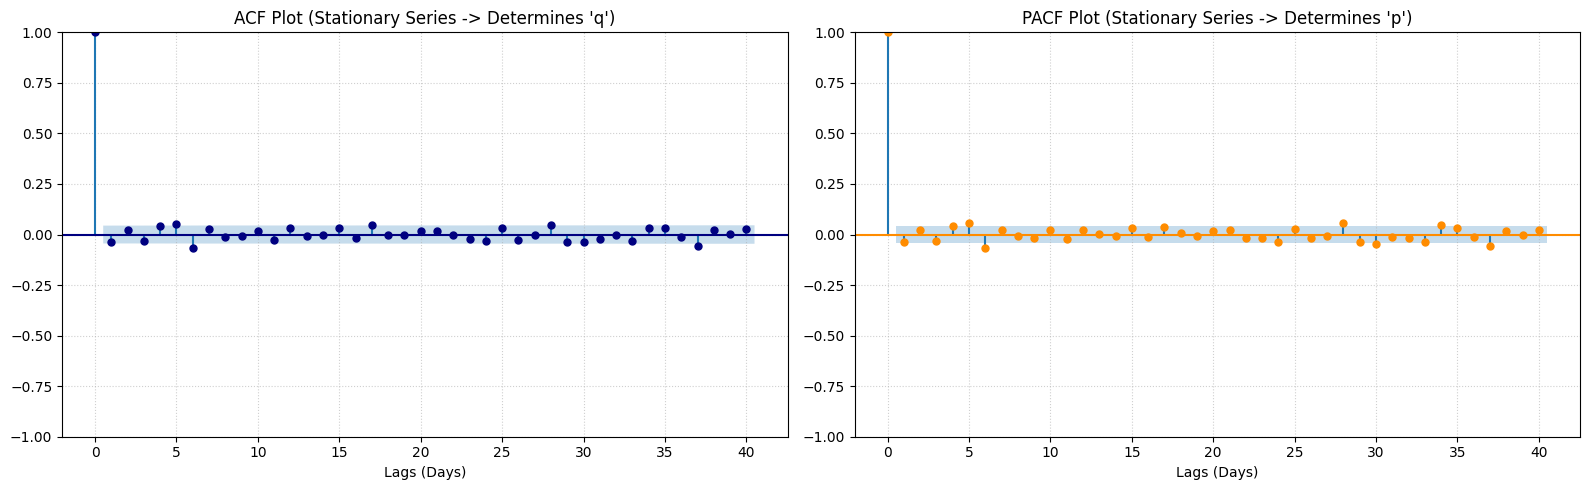

In [95]:
# Create a side-by-side subplot tracking structural correlation cut-offs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot ACF up to 40 days of lags to observe 'q' (Moving Average parameter boundary)
plot_acf(stationary_train, lags=40, ax=ax1, color='navy')
ax1.set_title("ACF Plot (Stationary Series -> Determines 'q')")
ax1.set_xlabel("Lags (Days)")
ax1.grid(True, linestyle=':', alpha=0.6)

# Plot PACF up to 40 days of lags to observe 'p' (AutoRegressive parameter boundary)
plot_pacf(stationary_train, lags=40, ax=ax2, color='darkorange', method='ywm')
ax2.set_title("PACF Plot (Stationary Series -> Determines 'p')")
ax2.set_xlabel("Lags (Days)")
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [96]:
print(f"Executing 80/20 Rolling Walk-Forward ARIMA Loop over {n_test} test slots...")
print("(This loops day-by-day to capture structural shifts and prevent flat lines)")

arima_rolling_preds = []
history_prices = list(train_series.values)

# Walk-forward loop over the 20% validation window
for t in range(n_test):
    if t % 100 == 0 or t == n_test - 1:
        print(f" Progress: Processing day {t}/{n_test}...")

    # Fit ARIMA(1,1,1) model using active timeline data
    model = ARIMA(history_prices, order=(1, 1, 1))
    fit_model = model.fit()

    # Extract tomorrow's step forecast
    pred = fit_model.forecast(steps=1)[0]
    arima_rolling_preds.append(pred)

    # Append the actual observed market price to step forward the timeline context
    history_prices.append(test_series.iloc[t])

arima_rolling_preds = np.array(arima_rolling_preds)

# Isolate Static Historical Training Residuals for the Neural Layer
initial_arima = ARIMA(train_series, order=(1, 1, 1)).fit()
train_residuals = initial_arima.resid.iloc[1:] # Drop first cell due to differencing alignment

# Isolate Out-of-Sample Test Residuals generated during evaluation step
test_residuals_actual = test_series.values - arima_rolling_preds

print("\nLinear compilation loop successful.")

Executing 80/20 Rolling Walk-Forward ARIMA Loop over 493 test slots...
(This loops day-by-day to capture structural shifts and prevent flat lines)
 Progress: Processing day 0/493...
 Progress: Processing day 100/493...
 Progress: Processing day 200/493...
 Progress: Processing day 300/493...
 Progress: Processing day 400/493...
 Progress: Processing day 492/493...

Linear compilation loop successful.


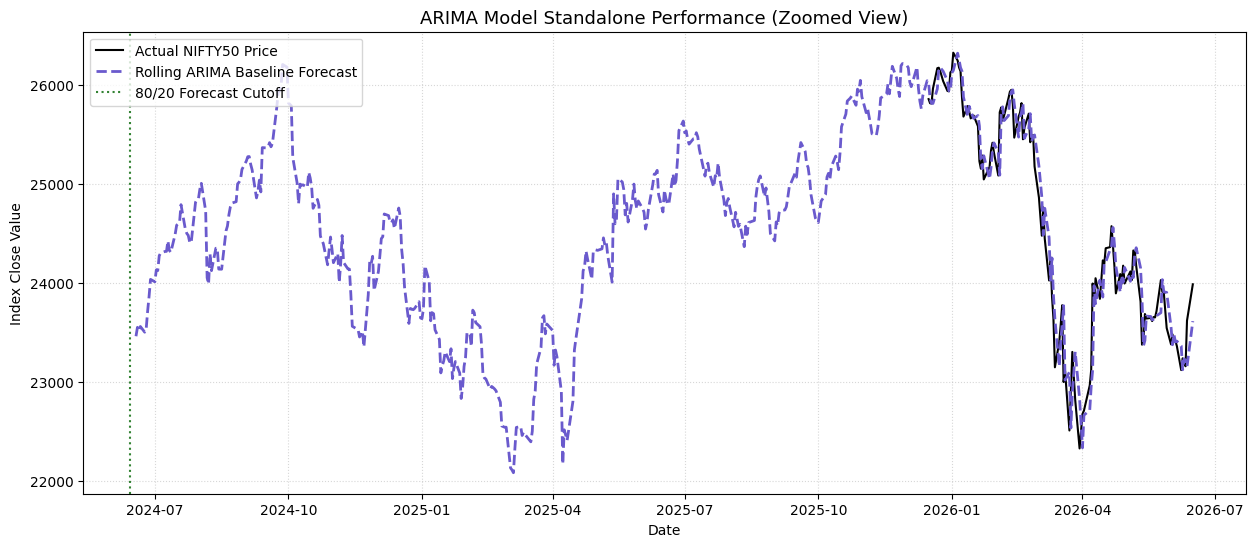

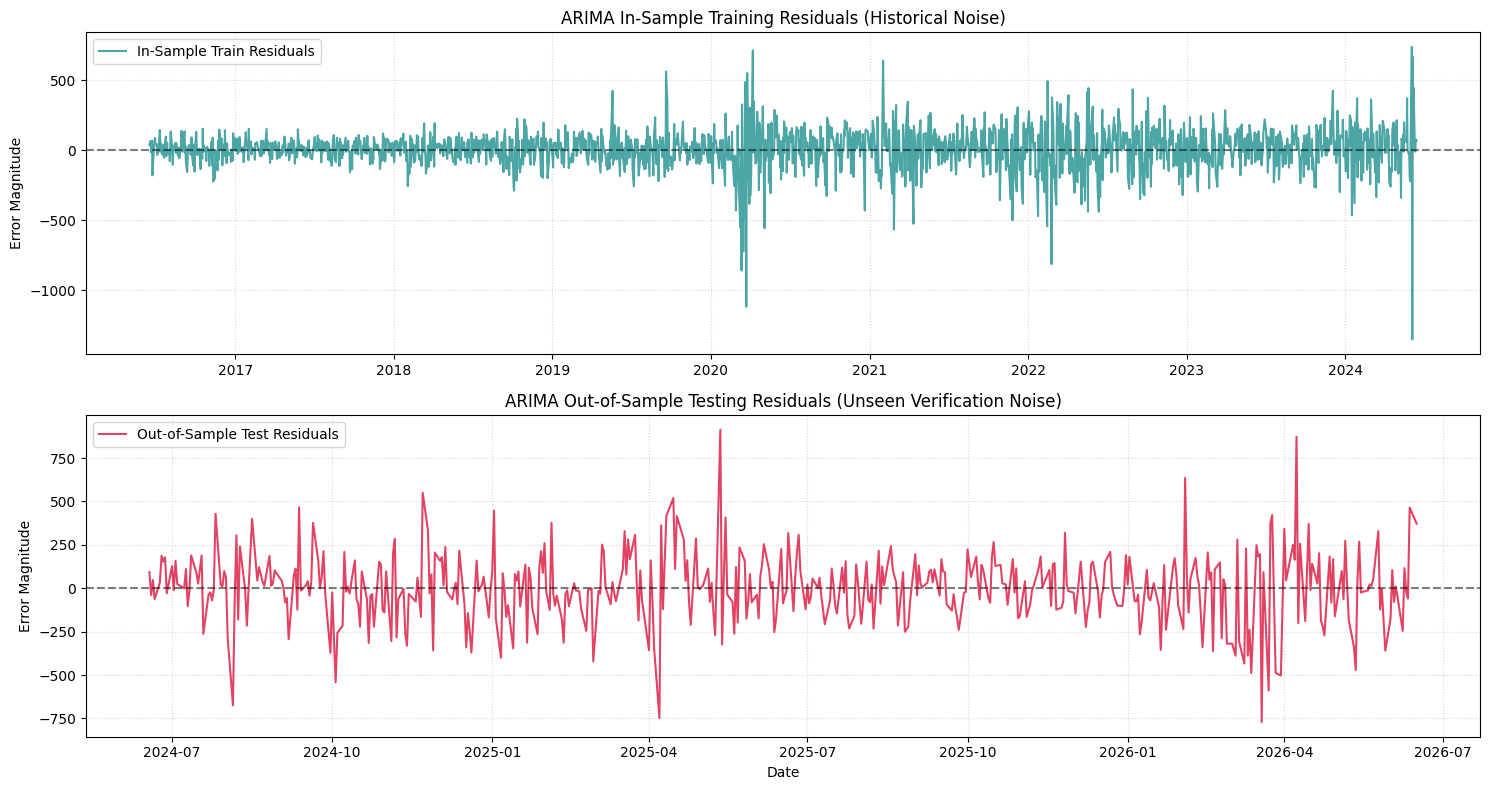

In [100]:
# =====================================================================
# INTERMEDIATE DIAGNOSTICS: ARIMA FORECAST & RESIDUAL ANALYSIS
# =====================================================================

# 1. Plotting the standalone Rolling ARIMA Forecast against Actual Prices
plt.figure(figsize=(15, 6))
plt.plot(series.index[-120:], series.iloc[-120:], label="Actual NIFTY50 Price", color='black', lw=1.5)
plt.plot(test_series.index, arima_rolling_preds, label="Rolling ARIMA Baseline Forecast", color='slateblue', lw=2, linestyle='--')
plt.axvline(x=train_series.index[-1], color='darkgreen', linestyle=':', alpha=0.8, label='80/20 Forecast Cutoff')
plt.title("ARIMA Model Standalone Performance (Zoomed View)", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Index Close Value")
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

# 2. Plotting the Training and Testing Residuals (The structural noise left behind)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharey=False)

# Subplot A: Training Residuals (In-sample errors)
ax1.plot(train_residuals.index, train_residuals.values, color='teal', alpha=0.7, label='In-Sample Train Residuals')
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax1.set_title("ARIMA In-Sample Training Residuals (Historical Noise)", fontsize=12)
ax1.set_ylabel("Error Magnitude")
ax1.legend(loc='upper left')
ax1.grid(True, linestyle=':', alpha=0.5)

# Subplot B: Testing Residuals (Out-of-sample errors)
ax2.plot(test_series.index, test_residuals_actual, color='crimson', alpha=0.8, label='Out-of-Sample Test Residuals')
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.set_title("ARIMA Out-of-Sample Testing Residuals (Unseen Verification Noise)", fontsize=12)
ax2.set_xlabel("Date")
ax2.set_ylabel("Error Magnitude")
ax2.legend(loc='upper left')
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [97]:
all_residuals = np.concatenate([train_residuals.values, test_residuals_actual])

# Transform residuals into [-1, 1] bounds for neural stability
res_scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_train_res = res_scaler.fit_transform(train_residuals.values.reshape(-1, 1))
scaled_all_res = res_scaler.transform(all_residuals.reshape(-1, 1))

# Set up a 10-day lookback sequence window
lookback = 10
X_train, y_train = [], []

for i in range(len(scaled_train_res) - lookback):
    X_train.append(scaled_train_res[i:(i + lookback), 0])
    y_train.append(scaled_train_res[i + lookback, 0])

X_train = np.array(X_train).reshape(-1, lookback, 1)
y_train = np.array(y_train)

print(f"LSTM Training Features Matrix Dimensions: {X_train.shape}")
print(f"LSTM Training Vector Target Dimensions:   {y_train.shape}")

LSTM Training Features Matrix Dimensions: (1958, 10, 1)
LSTM Training Vector Target Dimensions:   (1958,)


In [98]:
# 1. Define Deep Recurrent Sequence Layers
lstm_net = Sequential([
    LSTM(64, return_sequences=True, input_shape=(lookback, 1)),
    LSTM(32, return_sequences=False),
    Dense(16),
    Dense(1)
])
lstm_net.compile(optimizer='adam', loss='mean_squared_error')

print("Fitting LSTM layers on structural residual errors...")
lstm_net.fit(X_train, y_train, epochs=12, batch_size=32, verbose=1)
print("Neural training sequence completed.")

# 2. Execute Rolling Walk-Forward Prediction for Evaluation Space Residuals
lstm_rolling_res_preds = []

# Locate index split line separating train records from testing blocks within unified array
start_idx = len(scaled_train_res)

for t in range(n_test):
    # Dynamically extract lookback frame based on actual past realized error data
    current_lookup_frame = scaled_all_res[(start_idx + t - lookback):(start_idx + t), 0]
    lstm_input = current_lookup_frame.reshape(1, lookback, 1)

    # Predict next step non-linear deviation correction
    scaled_pred_res = lstm_net.predict(lstm_input, verbose=0)[0, 0]
    unscaled_pred_res = res_scaler.inverse_transform([[scaled_pred_res]])[0, 0]
    lstm_rolling_res_preds.append(unscaled_pred_res)

lstm_rolling_res_preds = np.array(lstm_rolling_res_preds)
print("Residual forecasting loop successful.")

Fitting LSTM layers on structural residual errors...
Epoch 1/12
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0256
Epoch 2/12
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0183
Epoch 3/12
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0182
Epoch 4/12
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0181
Epoch 5/12
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0181
Epoch 6/12
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0181
Epoch 7/12
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0181
Epoch 8/12
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0180
Epoch 9/12
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0180
Epoch 10/12
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0180
Epoch 11/12
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0180
Epoch 12/12
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0180
Neural training sequence completed.
Residual forecasting loop successful.



================ SYSTEM EVALUATION WINDOW PERFORMANCE ================
RMSE (Root Mean Squared Error): 201.80
MAE  (Mean Absolute Error):     148.18
MAPE (Mean Absolute Percentage): 0.61%


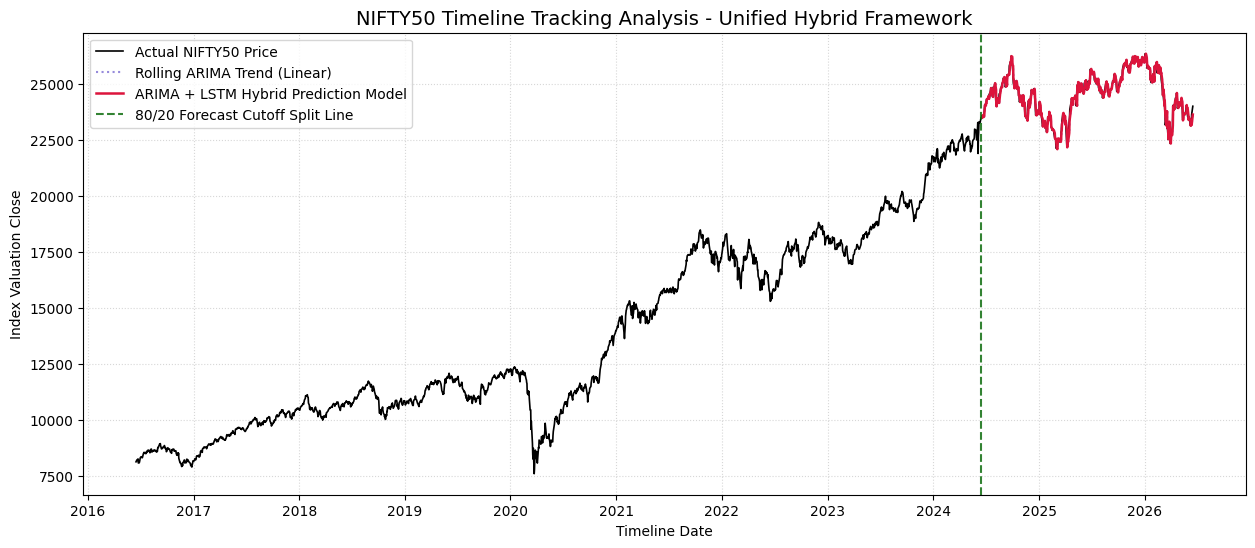

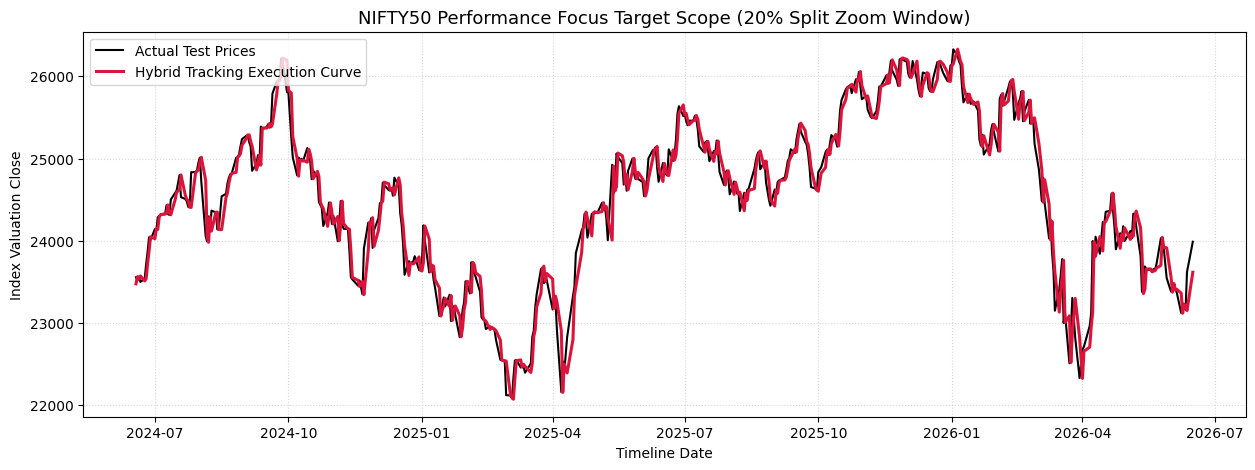

In [99]:
# 1. Superimpose Linear Trend Baseline + Non-Linear Error Resolution
final_hybrid_preds = arima_rolling_preds + lstm_rolling_res_preds

# 2. Compute Target Evaluation Statistical Metrics
actual_test_values = test_series.values
mae = np.mean(np.abs(actual_test_values - final_hybrid_preds))
rmse = np.sqrt(np.mean((actual_test_values - final_hybrid_preds)**2))
mape = np.mean(np.abs((actual_test_values - final_hybrid_preds) / actual_test_values)) * 100

print(f"\n================ SYSTEM EVALUATION WINDOW PERFORMANCE ================")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"MAE  (Mean Absolute Error):     {mae:.2f}")
print(f"MAPE (Mean Absolute Percentage): {mape:.2f}%")
print(f"=======================================================================")

# 3. Plot Full Dataset Scope Timeline
plt.figure(figsize=(15, 6))
plt.plot(series.index, series, label="Actual NIFTY50 Price", color='black', lw=1.2)
plt.plot(test_series.index, arima_rolling_preds, label="Rolling ARIMA Trend (Linear)", color='slateblue', linestyle=':', alpha=0.7)
plt.plot(test_series.index, final_hybrid_preds, label="ARIMA + LSTM Hybrid Prediction Model", color='crimson', lw=1.8)
plt.axvline(x=train_series.index[-1], color='darkgreen', linestyle='--', alpha=0.8, label='80/20 Forecast Cutoff Split Line')
plt.title("NIFTY50 Timeline Tracking Analysis - Unified Hybrid Framework", fontsize=14)
plt.xlabel("Timeline Date")
plt.ylabel("Index Valuation Close")
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

# 4. Plot Focused Isolated Zoomed View of the 20% Evaluation Window
plt.figure(figsize=(15, 5))
plt.plot(test_series.index, actual_test_values, label="Actual Test Prices", color='black', lw=1.5)
plt.plot(test_series.index, final_hybrid_preds, label="Hybrid Tracking Execution Curve", color='crimson', lw=2.2)
plt.title("NIFTY50 Performance Focus Target Scope (20% Split Zoom Window)", fontsize=13)
plt.xlabel("Timeline Date")
plt.ylabel("Index Valuation Close")
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

====================== BACKTEST PERFORMANCE ======================
Total Trading Days Evaluated: 493
Correct Directional Predictions: 258 days
True Directional Win Rate: 52.33%
Buy & Hold NIFTY50 Return:       2.23%
Hybrid ARIMA+LSTM Strategy Return: 17.40%


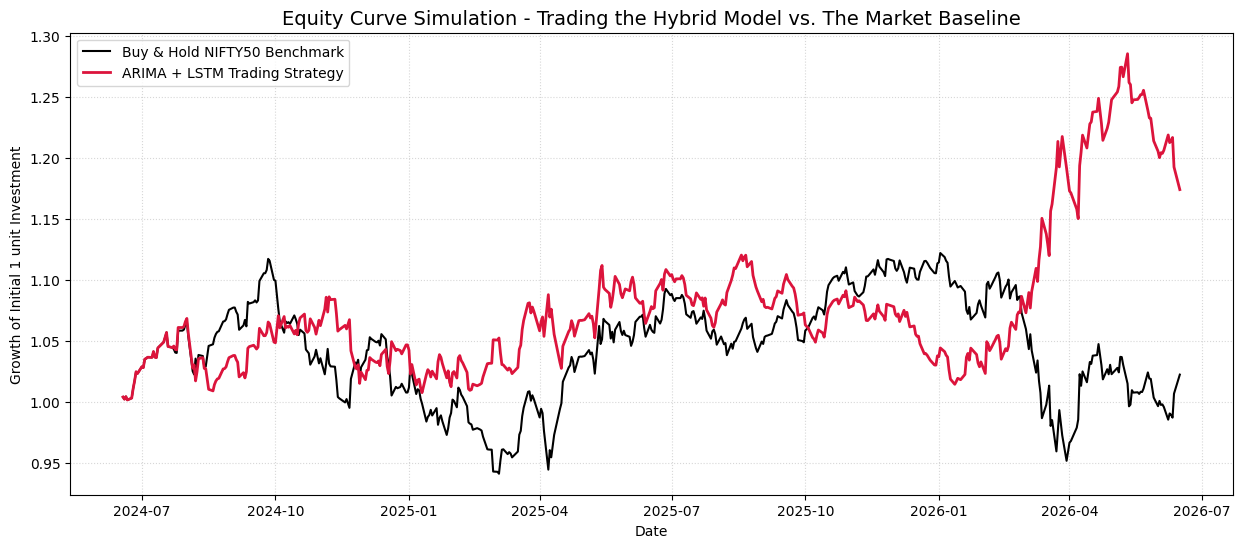

In [101]:
# =====================================================================
# SYSTEM REALITY CHECK: DIRECTIONAL ACCURACY & TRADING BACKTEST
# =====================================================================

# 1. Align the actual values and predictions
# To know if the model correctly predicts 'Up' or 'Down', we must compare
# the predicted change to the actual change relative to YESTERDAY's true price.

actual_prices = test_series.values
predicted_prices = final_hybrid_preds

# We need the last price of the training set to calculate the direction for the very first test day
last_train_price = train_series.iloc[-1]
yesterday_prices = np.insert(actual_prices[:-1], 0, last_train_price)

# Calculate True Direction vs Predicted Direction
# 1 = Market went Up, 0 = Market went Down/Flat
true_direction = np.where(actual_prices > yesterday_prices, 1, 0)
pred_direction = np.where(predicted_prices > yesterday_prices, 1, 0)

# Calculate Directional Win Rate
correct_directions = (true_direction == pred_direction)
win_rate = np.mean(correct_directions) * 100

print("====================== BACKTEST PERFORMANCE ======================")
print(f"Total Trading Days Evaluated: {len(actual_prices)}")
print(f"Correct Directional Predictions: {np.sum(correct_directions)} days")
print(f"True Directional Win Rate: {win_rate:.2f}%")
print("==================================================================")

# 2. Simulate a Long/Short Trading Strategy
# Strategy Rules:
# If model predicts tomorrow will go UP -> Buy/Hold Long (Position = +1)
# If model predicts tomorrow will go DOWN -> Short/Stay Cash (Position = -1)

# Daily market returns
market_daily_returns = (actual_prices - yesterday_prices) / yesterday_prices

# Strategy returns: if position is -1 and market goes down, we make a profit
strategy_positions = np.where(predicted_prices > yesterday_prices, 1, -1)
strategy_daily_returns = strategy_positions * market_daily_returns

# Calculate Cumulative Growth of 1 Rupee invested
cumulative_market_growth = np.cumprod(1 + market_daily_returns)
cumulative_strategy_growth = np.cumprod(1 + strategy_daily_returns)

# Final ROI Percentages
market_roi = (cumulative_market_growth[-1] - 1) * 100
strategy_roi = (cumulative_strategy_growth[-1] - 1) * 100

print(f"Buy & Hold NIFTY50 Return:       {market_roi:.2f}%")
print(f"Hybrid ARIMA+LSTM Strategy Return: {strategy_roi:.2f}%")
print("==================================================================")

# 3. Plotting the Financial Truth
plt.figure(figsize=(15, 6))
plt.plot(test_series.index, cumulative_market_growth, label="Buy & Hold NIFTY50 Benchmark", color='black', lw=1.5)
plt.plot(test_series.index, cumulative_strategy_growth, label="ARIMA + LSTM Trading Strategy", color='crimson', lw=2)
plt.title("Equity Curve Simulation - Trading the Hybrid Model vs. The Market Baseline", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Growth of Initial 1 unit Investment")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()